In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix


In [ ]:
file_path = '/kaggle/input/predict-ovarian-cancer/Supplementary data 1.xlsx'
df = pd.read_excel(file_path)
print("Data loaded successfully.")

if 'SUBJECT_ID' in df.columns:
    df.drop('SUBJECT_ID', axis=1, inplace=True)

Data loaded successfully.


In [ ]:
# Define the clinical and hematological feature names
hematological_features = ['BASO#', 'BASO%', 'EO#', 'EO%', 'HCT', 'HGB', 'LYM#', 'LYM%', 'MCH', 'MCV', 'MONO#', 'MONO%', 'MPV', 'NEU', 'PCT', 'PDW', 'PLT', 'RBC', 'RDW']
clinical_features = ['AG', 'Age', 'ALB', 'ALP', 'ALT', 'AST', 'BUN', 'Ca', 'CL', 'CO2CP', 'CREA', 'DBIL', 'GGT', 'GLO', 'GLU.', 'IBIL', 'K', 'Menopause', 'Mg', 'Na', 'PHOS', 'TBIL', 'TP', 'UA']
# Combine the lists
clin_hem_features = hematological_features + clinical_features


In [ ]:
file_path = '/kaggle/input/predict-ovarian-cancer/Supplementary data 1.xlsx'
df = pd.read_excel(file_path)
print("Data loaded successfully.")

if 'SUBJECT_ID' in df.columns:
    df.drop('SUBJECT_ID', axis=1, inplace=True)

object_columns_in_set = df[clin_hem_features].select_dtypes(include=['object']).columns.tolist()

# Define cleaning function 
def clean_numeric_columns(df_in, columns):
    df_out = df_in.copy()
    def clean_value(x):
        if pd.isna(x): return np.nan
        if isinstance(x, (int, float)): return float(x)
        if isinstance(x, str):
            cleaned = re.sub(r'\\t|\s+', '', x)
            try: return float(cleaned)
            except ValueError: return np.nan
        return np.nan
    for col in columns:
        df_out[col] = df_out[col].apply(clean_value).astype(float)
    return df_out

if object_columns_in_set:
    print(f"Object columns to clean in clin/hem set: {object_columns_in_set}")
    df = clean_numeric_columns(df, object_columns_in_set)
    print("Numeric columns cleaned.")
else:
    print("No object-type columns found in the selected clinical/hematological features.")


Data loaded successfully.
No object-type columns found in the selected clinical/hematological features.


In [ ]:
# Re-using imputation logic and distributions defined previously
BIOMARKER_DISTRIBUTIONS = {
   'AFP': {'mean': 5, 'std': 2.5, 'units': 'ng/mL'},
   'CA125': {'mean': 17, 'std': 9, 'units': 'U/mL' },
   'CA19-9': {'mean': 18, 'std': 9.5, 'units': 'U/mL' },
   'CA72-4': {'mean': 3.5, 'std': 1.7, 'units': 'U/mL' },
   'HE4': {'mean': 70, 'std': 20, 'units': 'pmol/L'},
   'AG': {'mean': 12, 'std': 2, 'units': 'mEq/L'},
   'ALB': {'mean': 4.4, 'std': 0.5, 'units': 'g/dL'},
   'ALP': {'mean': 80, 'std': 30, 'units': 'IU/L'},
   'ALT': {'mean': 30, 'std': 12, 'units': 'IU/L'},
   'AST': {'mean': 28, 'std': 10, 'units': 'IU/L' },
   'CO2CP': {'mean': 26, 'std': 1.5, 'units': 'mEq/L'},
   'DBIL': {'mean': 0.15, 'std': 0.1, 'units': 'mg/dL'},
   'GGT': {'mean': 15, 'std': 7, 'units': 'U/L'},
   'GLO': {'mean': 2.9, 'std': 0.3, 'units': 'g/dL' },
   'IBIL': { 'mean': 0.5, 'std': 0.2,  'units': 'mg/dL'},
   'MPV': { 'mean': 9.5, 'std': 1, 'units': 'fL'},
   'NEU': {'mean': 4.75, 'std': 1.5, 'units': '10^3/μL'},
   'PCT': {'mean': 0.1, 'std': 0.2, 'units': 'ng/mL'},
   'PDW': {'mean': 13, 'std': 2, 'units': '%'},
   'TBIL': {'mean': 0.75, 'std': 0.3,  'units': 'mg/dL' },
   'TP': { 'mean': 7.15,  'std': 0.5,  'units': 'g/dL' }
}

def generate_biomarker_imputation(df_in, biomarkers=None, seed=42):
    imputed_df_out = df_in.copy()
    np.random.seed(seed)
    if biomarkers is None:
        biomarkers = list(BIOMARKER_DISTRIBUTIONS.keys())
    imputation_details_out = {}
    for marker in biomarkers:
        if marker not in imputed_df_out.columns or not imputed_df_out[marker].isna().any():
            continue
        dist_params = BIOMARKER_DISTRIBUTIONS[marker]
        missing_mask = imputed_df_out[marker].isna()
        n_missing = missing_mask.sum()
        impute_values = np.random.normal(
            loc=dist_params['mean'], scale=dist_params['std'], size=n_missing
        )
        impute_values[impute_values < 0] = 0 # Ensure non-negative
        imputed_df_out.loc[missing_mask, marker] = impute_values
        imputation_details_out[marker] = {'n_imputed': n_missing, 'imputation_mean': dist_params['mean'], 'imputation_std': dist_params['std'], 'units': dist_params['units']}
    return imputed_df_out, imputation_details_out

# Impute missing values for clinical/hematological features in BIOMARKER_DISTRIBUTIONS
features_to_impute_dist = [f for f in clin_hem_features if f in BIOMARKER_DISTRIBUTIONS and df[f].isnull().any()]
df_imputed, details = generate_biomarker_imputation(df, biomarkers=features_to_impute_dist)
print("Imputation details (Normal Distribution):", details)

# Impute remaining NaNs in selected clinical/hematological features with their respective means
for col in clin_hem_features:
   if df_imputed[col].isnull().any():
       mean_val = df_imputed[col].mean()
       df_imputed[col].fillna(mean_val, inplace=True)
       print(f"Filled remaining NaNs in '{col}' with mean: {mean_val:.4f}")


Imputation details (Normal Distribution): {'MPV': {'n_imputed': 2, 'imputation_mean': 9.5, 'imputation_std': 1, 'units': 'fL'}, 'NEU': {'n_imputed': 91, 'imputation_mean': 4.75, 'imputation_std': 1.5, 'units': '10^3/μL'}, 'PCT': {'n_imputed': 2, 'imputation_mean': 0.1, 'imputation_std': 0.2, 'units': 'ng/mL'}, 'PDW': {'n_imputed': 2, 'imputation_mean': 13, 'imputation_std': 2, 'units': '%'}, 'AG': {'n_imputed': 1, 'imputation_mean': 12, 'imputation_std': 2, 'units': 'mEq/L'}, 'ALB': {'n_imputed': 10, 'imputation_mean': 4.4, 'imputation_std': 0.5, 'units': 'g/dL'}, 'ALP': {'n_imputed': 10, 'imputation_mean': 80, 'imputation_std': 30, 'units': 'IU/L'}, 'ALT': {'n_imputed': 10, 'imputation_mean': 30, 'imputation_std': 12, 'units': 'IU/L'}, 'AST': {'n_imputed': 10, 'imputation_mean': 28, 'imputation_std': 10, 'units': 'IU/L'}, 'CO2CP': {'n_imputed': 1, 'imputation_mean': 26, 'imputation_std': 1.5, 'units': 'mEq/L'}, 'DBIL': {'n_imputed': 10, 'imputation_mean': 0.15, 'imputation_std': 0.1, 

In [14]:
# --- Step 3: Prepare Data for Model ---
X_ch = df_imputed[clin_hem_features] # Features: Clinical + Hematological
y_ch = df_imputed['TYPE']           # Target

print("\nClinical/Hematological Feature matrix shape:", X_ch.shape)
print("Target vector shape:", y_ch.shape)

# Split data
X_train_ch, X_test_ch, y_train_ch, y_test_ch = train_test_split(X_ch, y_ch, test_size=0.2, random_state=42, stratify=y_ch)

# Scale features
scaler_ch = MinMaxScaler()
X_train_ch_scaled = scaler_ch.fit_transform(X_train_ch)
X_test_ch_scaled = scaler_ch.transform(X_test_ch)
print("Clinical/Hematological features scaled.")



Clinical/Hematological Feature matrix shape: (349, 43)
Target vector shape: (349,)
Clinical/Hematological features scaled.


In [17]:
 # --- Step 4: Train Random Forest Model ---
rf_model_ch = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,             # Start with same parameters, tune if needed
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest model on Clinical/Hematological Features...")
rf_model_ch.fit(X_train_ch_scaled, y_train_ch)



Training Random Forest model on Clinical/Hematological Features...


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=3, min_samples_split=5,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [19]:
# --- Step 5: Evaluate Model ---
print("\nEvaluating model...")
y_pred_ch = rf_model_ch.predict(X_test_ch_scaled)

accuracy_ch = accuracy_score(y_test_ch, y_pred_ch)
balanced_accuracy_ch = balanced_accuracy_score(y_test_ch, y_pred_ch)
cm_ch = confusion_matrix(y_test_ch, y_pred_ch)
report_ch = classification_report(y_test_ch, y_pred_ch, target_names=['Benign', 'Ovarian Cancer'])

print(f"Test Accuracy (Clin/Hem): {accuracy_ch:.4f}")
print(f"Test Balanced Accuracy (Clin/Hem): {balanced_accuracy_ch:.4f}")
print("\nClassification Report (Clin/Hem):\n", report_ch)


Evaluating model...
Test Accuracy (Clin/Hem): 0.9000
Test Balanced Accuracy (Clin/Hem): 0.8995

Classification Report (Clin/Hem):
                 precision    recall  f1-score   support

        Benign       0.91      0.88      0.90        34
Ovarian Cancer       0.89      0.92      0.90        36

      accuracy                           0.90        70
     macro avg       0.90      0.90      0.90        70
  weighted avg       0.90      0.90      0.90        70



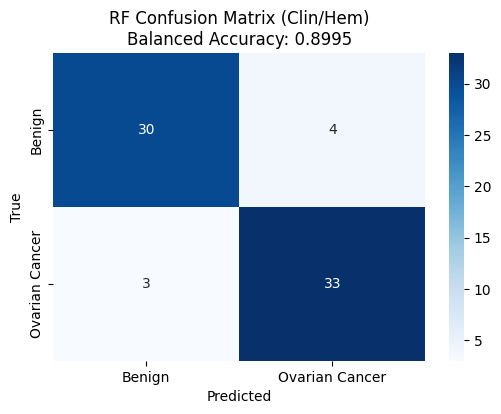

In [20]:
# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_ch, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Ovarian Cancer'],
            yticklabels=['Benign', 'Ovarian Cancer'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'RF Confusion Matrix (Clin/Hem)\nBalanced Accuracy: {balanced_accuracy_ch:.4f}')
plt.show()


In [ ]:
import joblib
import sklearn 

# Save the model
joblib.dump(rf_model_ch, 'rf_model_clin_hem.joblib')
print("Clinical/Hematological RF model saved as rf_model_clin_hem.joblib")

# Save the scaler
joblib.dump(scaler_ch, 'scaler_clin_hem.joblib')
print("Clinical/Hematological scaler saved as scaler_clin_hem.joblib")

Clinical/Hematological RF model saved as rf_model_clin_hem.joblib
Clinical/Hematological scaler saved as scaler_clin_hem.joblib
